<a href="https://colab.research.google.com/github/emmex43/Machine-learning-fantasy/blob/main/%22Predicting_Chemical_Process_Yield_Using_Linear_Regression%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"Predicting Chemical Process Yield Using Linear Regression"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [ ]:
# If running locally
# df = pd.read_csv('chemical_yield_dataset.csv')

# For Google Colab users (upload first)
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('chemical_yield_dataset.csv')

In [ ]:
df.head()
df.info()
df.describe()

# Check for missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature_K         300 non-null    float64
 1   Pressure_atm          300 non-null    float64
 2   Reaction_Time_min     300 non-null    float64
 3   Concentration_A_molL  300 non-null    float64
 4   Concentration_B_molL  300 non-null    float64
 5   Yield_kg              300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB
Temperature_K           0
Pressure_atm            0
Reaction_Time_min       0
Concentration_A_molL    0
Concentration_B_molL    0
Yield_kg                0
dtype: int64


Text(0.5, 1.0, 'Feature Correlation Heatmap')

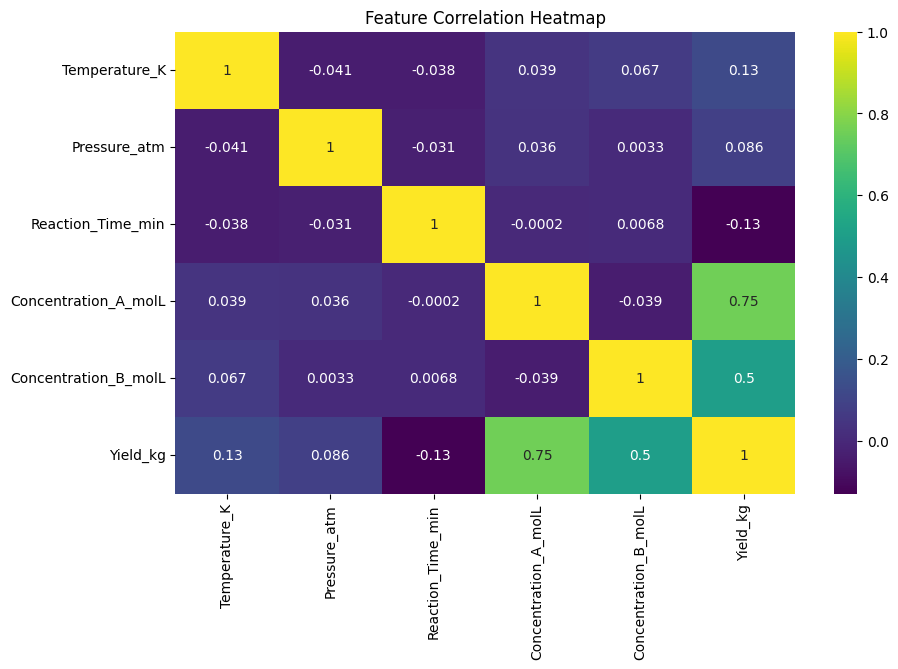

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation Heatmap")

# Pairplot (optional)
# sns.pairplot(df)


In [ ]:
X = df.drop('Yield_kg', axis=1)  # input features
y = df['Yield_kg']               # target output


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 2))


R² Score: 0.8832
Mean Absolute Error: 20.52


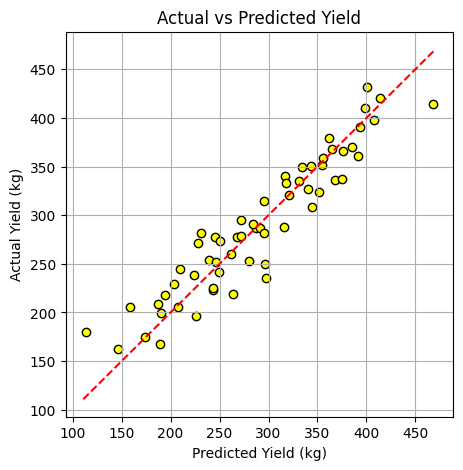

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, color='yellow', edgecolors='k')
plt.xlabel("Predicted Yield (kg)")
plt.ylabel("Actual Yield (kg)")
plt.title("Actual vs Predicted Yield")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect line
plt.grid(True)
plt.show()


In [ ]:
# predicting results for the actual and expected yield
print("Actual Yield (kg):", y_test.iloc[0])
print("Predicted Yield (kg):", y_pred[0])

Actual Yield (kg): 400.07868042217314
Predicted Yield (kg): 431.44506081946076
